In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn #nn contains all of pytorch's building blocks for neural networks
print(torch.__version__)
from torch import nn
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

2.5.1+cu121


Computer Vision

1.Getting a dataset

In [3]:
#setup training data
from torchvision import datasets
train_data=datasets.FashionMNIST(
    root="data",#where to download data to
    train=True,#do we want the training data?
    download=True,#do we want to download?
    transform=torchvision.transforms.ToTensor(),#how do we want to transform the data
    target_transform=None#how do we want transform the labels
)

test_data=datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

In [4]:
len(train_data),len(test_data)

(60000, 10000)

In [5]:
class_names=train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [6]:
class_to_idx=train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [7]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [8]:
image,label=train_data[0]
image,label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [9]:
#check the shape of our image
print(f"image shape:{image.shape}")#->[colour_channel,height,width]
print(f"image label:{class_names[label]}")

image shape:torch.Size([1, 28, 28])
image label:Ankle boot


image shape:torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

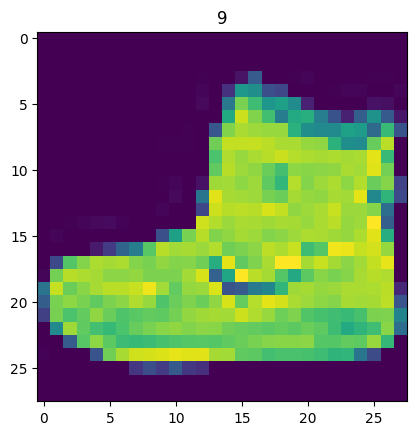

In [10]:
#1.2 Visualizing the data
image,label=train_data[0]
print(f"image shape:{image.shape}")

plt.imshow(image.squeeze())
plt.title(label)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

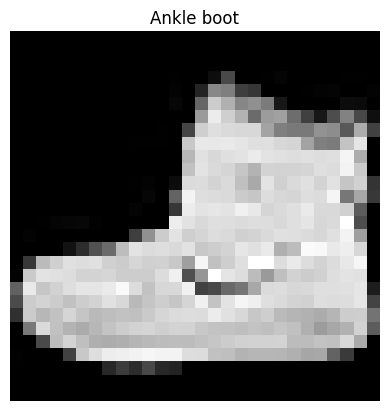

In [11]:
plt.imshow(image.squeeze(),cmap="gray")
plt.title(class_names[label])
plt.axis(False)

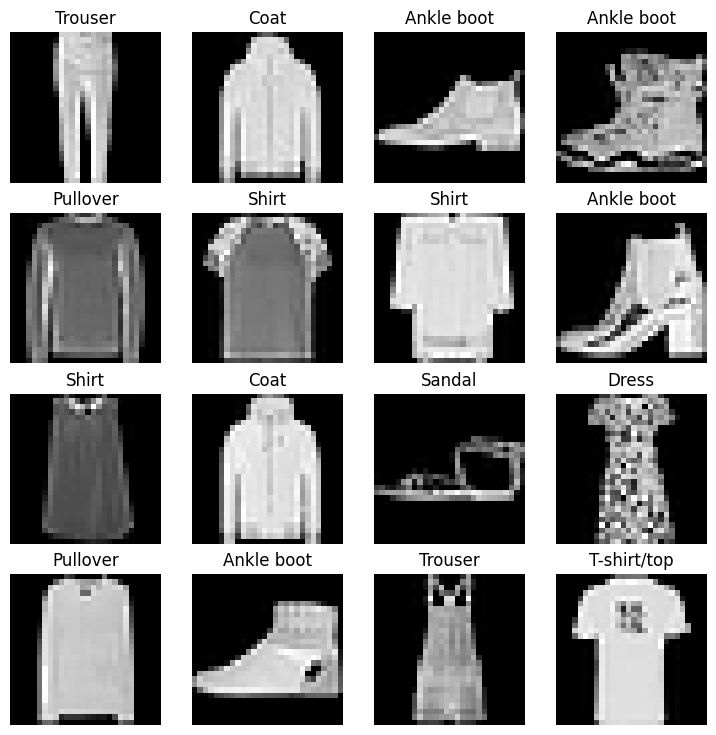

In [12]:
#plot more images 
# torch.manual_seed(42)
fig=plt.figure(figsize=(9,9))
row,col=4,4

for i in range(1,row*col+1):
    random_idx=torch.randint(0,len(train_data),size=[1]).item()
    img,lbl=train_data[random_idx]
    fig.add_subplot(row,col,i)
    plt.imshow(img.squeeze(),cmap="gray")
    plt.title(class_names[lbl])
    plt.axis(False)

2.Prepare dataloader

dataloader turns out data into a python iterable

we want to turn our data into mini batches

why would you do this?
1.it is more computationally efficient,as in your computing hardware may not be
able to look at 60000 images in one hit.so we break it down to 32 images at a time
2.it gives our neural network more changes to update its gradient per epoch.


In [13]:
from torch.utils.data import DataLoader

#setup the batch size hyperparameter
BATCH_SIZE=32

train_dataloader=DataLoader(dataset=train_data,
                            batch_size=BATCH_SIZE,
                            shuffle=True)

test_dataloader=DataLoader(dataset=test_data,
                           batch_size=BATCH_SIZE,
                           shuffle=False)

train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x28e8c53d970>,
 <torch.utils.data.dataloader.DataLoader at 0x28e8b00b530>)

In [14]:
print(f"dataloader:{train_dataloader,test_dataloader}")

dataloader:(<torch.utils.data.dataloader.DataLoader object at 0x0000028E8C53D970>, <torch.utils.data.dataloader.DataLoader object at 0x0000028E8B00B530>)


In [15]:
#check out what's inside the training dataloader
train_features_batch,train_label_batch=next(iter(train_dataloader))
train_features_batch.shape,train_label_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

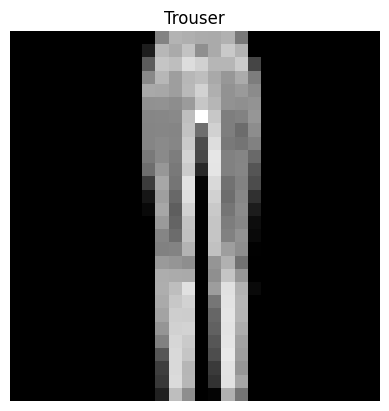

In [16]:
#show a sample
torch.manual_seed(42)
random_idx=torch.randint(0,len(train_features_batch),size=[1]).item()
img,lbl=train_features_batch[random_idx],train_label_batch[random_idx]
plt.imshow(img.squeeze(),cmap="gray")
plt.title(class_names[lbl])
plt.axis(False)


3.Model_0 the baseline model.
a baseline model is a simple model you will try and improve upon with subsequent models/experiment


In [17]:
#create a flatten layer
flatten_model=nn.Flatten()

#get a single sample
x=train_features_batch[0]

#flatten the sample
output=flatten_model(x)

#print out wha happened

print(f"{x.shape}")
print(f"{output.shape}")  

torch.Size([1, 28, 28])
torch.Size([1, 784])


In [18]:
class fashionMNIST(nn.Module):
    def __init__(self,input_shape:int,
                 hidden_units:int,
                 output_shape:int):
        super().__init__()
        self.layer_stack=nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape,out_features=hidden_units),
            nn.Linear(in_features=hidden_units,out_features=output_shape),
        )
    
    def forward(self,x):
        return self.layer_stack(x)
    

In [19]:
torch.manual_seed(42)

#setup model with input parameters
model_0=fashionMNIST(input_shape=28*28,
                     hidden_units=10,
                     output_shape=len(class_names)).to("cpu")

model_0

fashionMNIST(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [20]:
dummy_x=torch.rand([1,1,28,28])
model_0(dummy_x).shape

torch.Size([1, 10])

In [21]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.

In [22]:
#calculate the accuracy of our model
def accurracy_fn(y_true,y_pred):
    correct=torch.eq(y_true,y_pred).sum().item()
    acc=(correct/len(y_pred))*100
    return acc

In [23]:
#3.1 setup loss,optimizer and evaluation metrics
loss_fn=nn.CrossEntropyLoss()

optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.01)

In [24]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [25]:
from timeit import default_timer as timer

In [26]:
#3.3 creating a training loop and training the model on batches of data
#import tqdm for progess bar
from tqdm.auto import tqdm

#set the seed and start the timer
torch.manual_seed(420)
train_time_start_on_cpu=timer()

#set the number of epochs 
epochs=3

#create a training and test loop 
for epoch in tqdm(range(epochs)):
    print(f"Epoch:{epoch}")
    
    #training
    train_loss=0
    #add a loop through the training batches
    for batch,(X,y) in enumerate(train_dataloader):
        model_0.train()
        
        #1.forrward pass
        y_pred=model_0(X)
        
        #2.calculate loss(per batch)
        loss=loss_fn(y_pred,y)
        train_loss+=loss#accumlate train loss
        
        #3.optimizer zero grad
        optimizer.zero_grad()
        
        #4.loss backward
        loss.backward()
        
        #5.optimizer step
        optimizer.step()
        
        #print out what's happenening 
        if batch%400==0:
            print(f"looked at {batch*len(X)} {len(train_dataloader.dataset)}")
    
    #divide total train loss by length of train dataloader
    train_loss/=len(train_dataloader)
    
    #testing 
    test_loss,test_acc=0,0
    model_0.eval()
    
    with torch.inference_mode():
        for X_test,y_test in test_dataloader:
            #1.forward pass
            test_pred=model_0(X_test)
            
            #2.calculate loss
            test_loss+=loss_fn(test_pred,y_test)
            
            #3.calcualte accuracy
            test_acc+=accurracy_fn(y_true=y_test,y_pred=test_pred.argmax(dim=1))
        
        #calculate the test loss average per batch
        test_loss/=len(test_dataloader)
        
        #calculate the test acc average per batch
        test_acc/=len(test_dataloader)
        
    #printout what's happening
    print(f"\ntrain_loss:{train_loss:.4f} | test_loss:{test_loss:.4f} | test_acc:{test_acc:.4f}")        

c:\Users\Omkar Kadam\Desktop\PyTorch\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 0/3 [00:00<?, ?it/s]

Epoch:0
looked at 0 60000
looked at 12800 60000
looked at 25600 60000
looked at 38400 60000
looked at 51200 60000


 33%|███▎      | 1/3 [01:09<02:18, 69.06s/it]


train_loss:0.9084 | test_loss:0.6313 | test_acc:78.4245
Epoch:1
looked at 0 60000
looked at 12800 60000
looked at 25600 60000
looked at 38400 60000
looked at 51200 60000


 67%|██████▋   | 2/3 [02:24<01:13, 73.01s/it]


train_loss:0.5570 | test_loss:0.5474 | test_acc:81.1002
Epoch:2
looked at 0 60000
looked at 12800 60000
looked at 25600 60000
looked at 38400 60000
looked at 51200 60000


100%|██████████| 3/3 [03:33<00:00, 71.27s/it]


train_loss:0.5019 | test_loss:0.5106 | test_acc:82.3982


4.Make predictions

In [27]:
torch.manual_seed(42)
def eval_model(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               accurracy_fn):
    loss,acc=0,0
    model_0.eval()
    with torch.inference_mode():
        for X,y in data_loader:
            #make predictions
            y_pred=model(X)
            
            #accumulate the loss and acc values per batch
            loss+=loss_fn(y_pred,y)
            acc+=accurracy_fn(y_true=y,
                              y_pred=y_pred.argmax(dim=1))
        
        #scale the loss and acc to find the average loss/acc per batch
        loss/=len(data_loader)
        acc/=len(data_loader)
        

    return {"model name ":model.__class__.__name__,
            "model loss":loss.item(),
            "model_acc":acc}
    
#calculate model 0 results on test dataset
model_0_results=eval_model(model=model_0,
                           data_loader=test_dataloader,
                           loss_fn=loss_fn,
                           accurracy_fn=accurracy_fn)

model_0_results

{'model name ': 'fashionMNIST',
 'model loss': 0.5106381773948669,
 'model_acc': 82.39816293929712}

In [28]:
#set up device agnostic code
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

5.model_1:building a model with non-linearity

In [29]:
 #create a model with non-linear and linear layers
 
class fashionMNIST(nn.Module):
    def __init__(self,input_shape:int,
                 hidden_units:int,
                 output_shape:int):
        super().__init__()
        self.layer_stack=nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape,out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,out_features=output_shape),
            nn.ReLU()
        )
    
    def forward(self,x):
        return self.layer_stack(x)

In [30]:
torch.manual_seed(42)
model_1=fashionMNIST(input_shape=784,
                             hidden_units=10,
                             output_shape=len(class_names)).to(device)

next(model_1.parameters()).device

device(type='cuda', index=0)

In [31]:
#5.1 setup loss and optimizer
loss_fn=nn.CrossEntropyLoss()

optimizer=torch.optim.SGD(model_1.parameters(),lr=0.1)

In [32]:
#training loop 
def train_step(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               accurracy_fn,
               device:torch.device=device):
    
    #training
    train_loss,train_acc=0,0
    #add a loop through the training batches
    for batch,(X,y) in enumerate(data_loader):
        X,y=X.to(device),y.to(device)
        
        #1.forrward pass
        y_pred=model(X)
        
        #2.calculate loss(per batch)
        loss=loss_fn(y_pred,y)
        train_loss+=loss#accumlate train loss
        train_acc+=accurracy_fn(y_true=y,y_pred=y_pred.argmax(dim=1))
        #3.optimizer zero grad
        optimizer.zero_grad()
        
        #4.loss backward
        loss.backward()
        
        #5.optimizer step
        optimizer.step()
    
    #divide total train loss by length of train dataloader
    train_loss/=len(train_dataloader)
    train_acc/=len(data_loader)
    
    print(f"train_loss:{train_loss:.5f} | train_acc:{train_acc:.2f}%")
    
    

In [33]:
def test_step(model:torch.nn.Module,
              data_loader:torch.utils.data.DataLoader,
              loss_fn:torch.nn.Module,
              accurracy_fn,
              device:torch.device=device):
    
    test_loss,test_acc=0,0
    
    #put the model in eval model
    model.eval()
    
    #turn on inference mode context manager
    with torch.inference_mode():
        for X,y in data_loader:
            #send the data to the target device
            X,y=X.to(device),y.to(device)
            
            #1.forward pass
            test_pred=model(X)
            
            #2.calculate loss 
            test_loss+=loss_fn(test_pred,y)
            test_acc+=accurracy_fn(y_true=y,
                                   y_pred=test_pred.argmax(dim=1))
            
        #adjust metrics and printout
        test_loss/=len(data_loader)
        test_acc/=len(data_loader)
        print(f"test loss:{test_loss:.5f} | test_acc:{test_acc:.2f} ")    
            
    

In [34]:
torch.manual_seed(42)

#measure time
from timeit import default_timer as Timer
train_time_start_on_cpu=timer()

#set epochs 
epochs=3

#create a optimization and evaluation loop using train_step() and test_step()

for epoch in tqdm(range(epochs)):
    print(f"Epoch:{epoch}\n---------")
    train_step(model=model_1,
               data_loader=train_dataloader,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accurracy_fn=accurracy_fn,
               device=device)
    
    test_step(model=model_1,
              data_loader=test_dataloader,
              loss_fn=loss_fn,
              accurracy_fn=accurracy_fn,
              device=device)
    
train_time_end_on_cpu=timer()

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch:0
---------
train_loss:1.09199 | train_acc:61.34%


 33%|███▎      | 1/3 [01:02<02:05, 62.74s/it]

test loss:0.95636 | test_acc:65.00 
Epoch:1
---------
train_loss:0.78101 | train_acc:71.93%


 67%|██████▋   | 2/3 [02:04<01:02, 62.08s/it]

test loss:0.72227 | test_acc:73.91 
Epoch:2
---------
train_loss:0.67027 | train_acc:75.94%


100%|██████████| 3/3 [03:02<00:00, 60.80s/it]

test loss:0.68500 | test_acc:75.02 


In [35]:
model_0_results

{'model name ': 'fashionMNIST',
 'model loss': 0.5106381773948669,
 'model_acc': 82.39816293929712}

In [36]:
torch.manual_seed(42)
def eval_model(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               accurracy_fn,
               device:torch.device=device):
    loss,acc=0,0
    model.eval()
    with torch.inference_mode():
        for X,y in data_loader:
            #make predictions
            X,y=X.to(device),y.to(device)
            y_pred=model(X)
            
            #accumulate the loss and acc values per batch
            loss+=loss_fn(y_pred,y)
            acc+=accurracy_fn(y_true=y,
                              y_pred=y_pred.argmax(dim=1))
        
        #scale the loss and acc to find the average loss/acc per batch
        loss/=len(data_loader)
        acc/=len(data_loader)
        

    return {"model name ":model.__class__.__name__,
            "model loss":loss.item(),
            "model_acc":acc}

In [37]:
#get model_1 results dictionary
model_1_results=eval_model(model=model_1,
                           data_loader=test_dataloader,
                           loss_fn=loss_fn,
                           accurracy_fn=accurracy_fn,
                           device=device)

model_1_results

{'model name ': 'fashionMNIST',
 'model loss': 0.6850008368492126,
 'model_acc': 75.01996805111821}

Model_2:Building a Convolutional neural network 

In [38]:
#CNN
class fashionMNISTV2(nn.Module):
    def __init__(self,input_shape:int,
                 hidden_units:int,
                 output_shape:int):
        super().__init__()
        self.conv_block_1=nn.Sequential(
            nn.Conv2d(in_channels=input_shape,out_channels=hidden_units,kernel_size=1,stride=1,padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv_block_2=nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifer=nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7,#there is a trick for this
                      out_features=output_shape)
        )
        
    def forward(self,x):
        x=self.conv_block_1(x)
        x=self.conv_block_2(x)
        x=self.classifer(x)
        return x

In [39]:
torch.manual_seed(42)
model_2=fashionMNISTV2(input_shape=1,
                       hidden_units=10,
                       output_shape=len(class_names)).to(device)

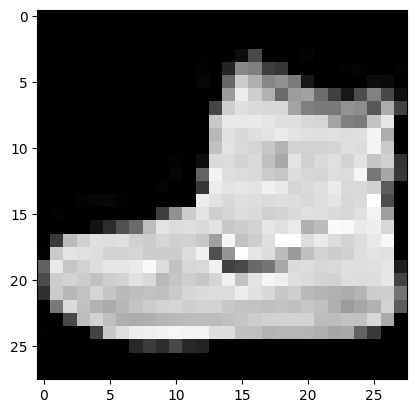

In [40]:
plt.imshow(image.squeeze(),cmap="gray")

In [41]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [42]:
rand_image_tensor=torch.rand(size=(1,28,28))
rand_image_tensor.shape

torch.Size([1, 28, 28])

In [43]:
model_2 = model_2.to(device)
rand_image_tensor = rand_image_tensor.to(device)
model_2(rand_image_tensor.unsqueeze(0))

tensor([[ 0.0366,  0.0007, -0.0107, -0.0240, -0.0059,  0.0756,  0.0342,  0.0027,
          0.0195,  0.0230]], device='cuda:0', grad_fn=<AddmmBackward0>)

7.stepping through nn.conv2d

In [44]:
torch.manual_seed(42)

#create a batch of images
images=torch.randn(size=(32,3,64,64))
test_image=images[0]
test_image.shape

torch.Size([3, 64, 64])

In [45]:
torch.manual_seed(42)
#create a conv2d single layer
conv_layer=nn.Conv2d(in_channels=3,out_channels=10,kernel_size=(3,3),stride=1,padding=1)

#pass the data throught the conv layer
conv_output=conv_layer(test_image.unsqueeze(0))
conv_output.shape

torch.Size([1, 10, 64, 64])

In [46]:
#7.2stepping thorugh nn.maxpool2D()
test_image.shape

torch.Size([3, 64, 64])

In [47]:
#create a sample nn.maxpool2d layer
max_pool_layer=nn.MaxPool2d(kernel_size=2)

#pass data through just the conv_layer
test_image_through_conv=conv_layer(test_image.unsqueeze(0))
print(f"shape after going through conv layer():{test_image_through_conv.shape}")

#pass the data through the max pool layer
test_image_through_and_max_pool=max_pool_layer(test_image_through_conv)
print(f"shape after going through conv and max pool layer():{test_image_through_and_max_pool.shape}")

shape after going through conv layer():torch.Size([1, 10, 64, 64])
shape after going through conv and max pool layer():torch.Size([1, 10, 32, 32])


In [48]:
torch.manual_seed(42)
#create a random tensor with a similar number of dimensions to our images
random_tensor=torch.randn(size=(1,1,2,2))
print(f"random tensor:{random_tensor}")
print(f"random tensor shape:{random_tensor.shape}")
#create a max pool layer
max_pool_layer=nn.MaxPool2d(kernel_size=2)

#pass the random tensor through the max pool layer
max_pool_tensor=max_pool_layer(random_tensor)
print(f"max_pool_tensor:{max_pool_tensor}")
print(f"max pool tensor shape :{max_pool_tensor.shape}")

random tensor:tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])
random tensor shape:torch.Size([1, 1, 2, 2])
max_pool_tensor:tensor([[[[0.3367]]]])
max pool tensor shape :torch.Size([1, 1, 1, 1])


In [49]:
#Setup the loss function and optimizer
loss_fn=nn.CrossEntropyLoss()

optimizer=torch.optim.SGD(params=model_2.parameters(),lr=0.01)

In [50]:
#7.3 training and testing model_2 using out train and test functions
torch.manual_seed(42)
torch.cuda.manual_seed(42)

#measure time
from timeit import default_timer as timer
train_time_start_model_2=timer()

#train the model
epochs=3

for epoch in tqdm(range(epochs)):
    print(f"epoch:{epoch}\n---------")
    train_step(model=model_2,
               data_loader=train_dataloader,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accurracy_fn=accurracy_fn,
               device=device)
    
    test_step(model=model_2,
               data_loader=test_dataloader,
               loss_fn=loss_fn,
               accurracy_fn=accurracy_fn,
               device=device)
    

train_timme_end_model_2=timer()

  0%|          | 0/3 [00:00<?, ?it/s]

epoch:0
---------
train_loss:1.00684 | train_acc:64.13%


 33%|███▎      | 1/3 [01:20<02:40, 80.38s/it]

test loss:0.59863 | test_acc:78.45 
epoch:1
---------
train_loss:0.52700 | train_acc:80.95%


 67%|██████▋   | 2/3 [02:37<01:18, 78.25s/it]

test loss:0.48506 | test_acc:81.88 
epoch:2
---------
train_loss:0.43890 | train_acc:84.20%


100%|██████████| 3/3 [03:45<00:00, 75.04s/it]

test loss:0.43380 | test_acc:84.53 


In [51]:
#get model_2 results
model_2_results=eval_model(model=model_2,
                           data_loader=test_dataloader,
                           loss_fn=loss_fn,
                           accurracy_fn=accurracy_fn,
                           device=device)

model_2_results

{'model name ': 'fashionMNISTV2',
 'model loss': 0.4338025450706482,
 'model_acc': 84.53474440894568}

8.Compare model results andd training time


In [52]:
compare_results=pd.DataFrame([model_0_results,
                             model_1_results,
                             model_2_results])

compare_results

,model name,model loss,model_acc
0,fashionMNIST,0.510638,82.398163
1,fashionMNIST,0.685001,75.019968
2,fashionMNISTV2,0.433803,84.534744


In [53]:
def make_predictions(model:torch.nn.Module,
                     data:list,
                     device:torch.device=device):
    pred_probs=[]
    model.eval()
    with torch.inference_mode():
        for sample in data:
            #prepare the sample 
            sample=torch.unsqueeze(sample,dim=0).to(device)
            
            #foward pass
            pred_logit=model(sample)
            
            #get prediction probablitity
            pred_prob=torch.softmax(pred_logit.squeeze(),dim=0)
            
            #get pred_prob off the gpu for further calculations
            pred_probs.append(pred_prob.cpu())
        
    #stack the pred_probs to turn list into tensor
    return torch.stack(pred_probs)
        

In [54]:
import random
random.seed(42)
test_samples=[]
test_labels=[]

for sample,label in random.sample(list(test_data),k=9):
    test_samples.append(sample)
    test_labels.append(label)
    
    #view the first sample shape
    test_samples[0].shape


In [55]:
#make predictions
pred_probs=make_predictions(model=model_2,
                            data=test_samples)

pred_probs[:2]

tensor([[8.8756e-07, 1.0280e-06, 1.3865e-07, 2.6130e-07, 7.7452e-08, 9.2245e-01,
         1.0360e-06, 2.6372e-04, 1.2094e-04, 7.7166e-02],
        [9.5314e-02, 2.0176e-01, 9.7013e-04, 6.5618e-01, 2.3842e-02, 4.9485e-06,
         2.1329e-02, 1.0596e-04, 4.7793e-04, 1.1404e-05]])

In [56]:
#convert predictions probablities to labels
pred_classes=pred_probs.argmax(dim=1)
pred_classes

tensor([5, 3, 7, 4, 3, 0, 4, 7, 1])

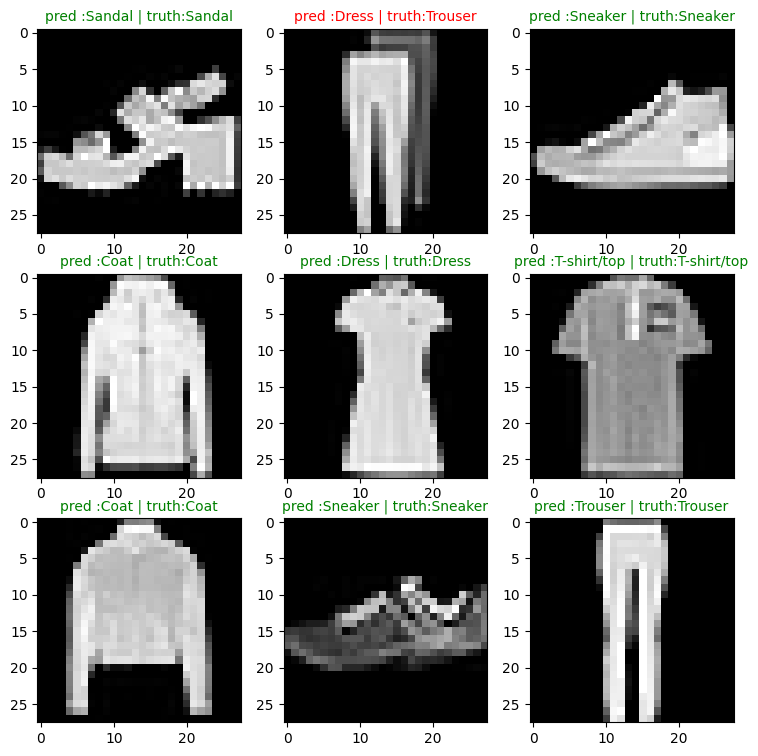

In [58]:
#plot predictions
plt.figure(figsize=(9,9))
nrows=3
ncols=3

for i,sample in enumerate(test_samples):
    #create subplot
    plt.subplot(nrows,ncols,i+1)
    
    #plot the target image
    plt.imshow(sample.squeeze(),cmap="gray")
    
    #find the prediction 
    pred_label=class_names[pred_classes[i]]
    
    #get the truth label
    truth_label=class_names[test_labels[i]]
    
    #create a title for the plot
    title_next=f"pred :{pred_label} | truth:{truth_label}"
    
    #check for equally betwwen pred and truth and change colour of title text
    if pred_label==truth_label:
        plt.title(title_next,fontsize=10,c="g")
    else:
        plt.title(title_next,fontsize=10,c="r")

In [61]:
pip install mlxtend

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 14.0 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [62]:
import mlxtend

In [ ]:
from tqdm.auto import tqdm

#make predictions with trained model
y_preds=[]
model_2.eval()
with torch.inference_mode():
    for X,y in tqdm(test_dataloader,desc="making predictions"):
        #send the data and targets to target device
        X,y=X.to(device),y.to(device)
        
        #do the forward pass
        y_logit=model_2(X)
        
        #turn predictions from logits->predictions probalblities->predictions labels
        y_pred=torch.softmax(y_logit.squeeze(),dim=0).argmax(dim=1)
        
        #put prediction on CPU for evaluation
        y_preds.append(y_pred.cpu())
    
# print(y_preds)
y_pred_tensor=torch.cat(y_preds)
y_pred_tensor
        
        

making predictions: 100%|██████████| 313/313 [00:03<00:00, 102.00it/s]


tensor([9, 2, 1,  ..., 8, 1, 8])